# Exploratory Data Analysis

**Goal:** understand the structure, properties, and relationships of the data before building regression and simulation models.

**Dataset:** `quarterly_data.xlsx`
- Time period: 2017Q1-2024Q4 (= 32 quarters)
- 1 missing value: CAR in 2022Q1 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, mannwhitneyu, spearmanr

import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_excel("../../data_processed/quarterly_data.xlsx")
df = df.drop(columns=["ROE"]) 
display(df.head(5))

print("df.info():\n")
display(df.info())

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital
0,2017Q1,13.966667,27.049589,14.000000,0.028,55.106022,13.72,1.64,9.855700e+05,152903.000000
1,2017Q2,13.766667,26.334408,12.666667,0.027,57.732746,12.42,-0.27,9.727767e+05,140489.687451
2,2017Q3,16.166667,26.005408,12.500000,0.023,56.435632,15.27,0.15,9.920560e+05,168746.000000
3,2017Q4,13.966667,27.303514,13.833333,0.022,54.541296,16.10,-1.93,1.036745e+06,161108.000000
4,2018Q1,13.766667,27.166823,16.333333,0.035,56.446150,16.49,2.66,1.059884e+06,159081.000000


df.info():

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         32 non-null     object 
 1   CPI          32 non-null     float64
 2   usd_uah      32 non-null     float64
 3   policy_rate  32 non-null     float64
 4   gdp_growth   32 non-null     float64
 5   NPL          32 non-null     float64
 6   CAR          31 non-null     float64
 7   ROA          32 non-null     float64
 8   loans        32 non-null     float64
 9   capital      32 non-null     float64
dtypes: float64(9), object(1)
memory usage: 2.6+ KB


None

## Descriptive Statistics

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns

stats_table = pd.DataFrame(index=num_cols)

stats_table["min"]          = df[num_cols].min()
stats_table["q25"]          = df[num_cols].quantile(0.25)
stats_table["median"]       = df[num_cols].median()
stats_table["mean"]         = df[num_cols].mean()
stats_table["q75"]          = df[num_cols].quantile(0.75)
stats_table["max"]          = df[num_cols].max()
stats_table["std"]          = df[num_cols].std()
stats_table["missing_count"]= df[num_cols].isna().sum()

stats_table.round(3)

,min,q25,median,mean,q75,max,std,missing_count
CPI,2.067,6.683,9.450,10.675,13.817,26.567,6.231,0
usd_uah,24.239,26.836,27.800,30.515,36.569,41.638,5.424,0
policy_rate,6.000,10.500,14.417,14.562,17.542,25.000,5.636,0
gdp_growth,-0.366,-0.012,0.027,-0.013,0.039,0.193,0.119,0
NPL,27.065,35.692,40.469,43.187,51.969,57.733,9.594,0
CAR,12.420,16.725,19.070,18.930,21.330,24.990,2.950,1
ROA,-1.930,1.230,3.110,2.821,4.345,5.860,2.075,0
loans,960597.000,1001591.500,1039637.000,1047283.798,1087939.500,1147230.000,51753.882,0
capital,140489.687,168195.500,208517.000,222638.303,251087.500,391882.000,68854.571,0


## Time series visualization

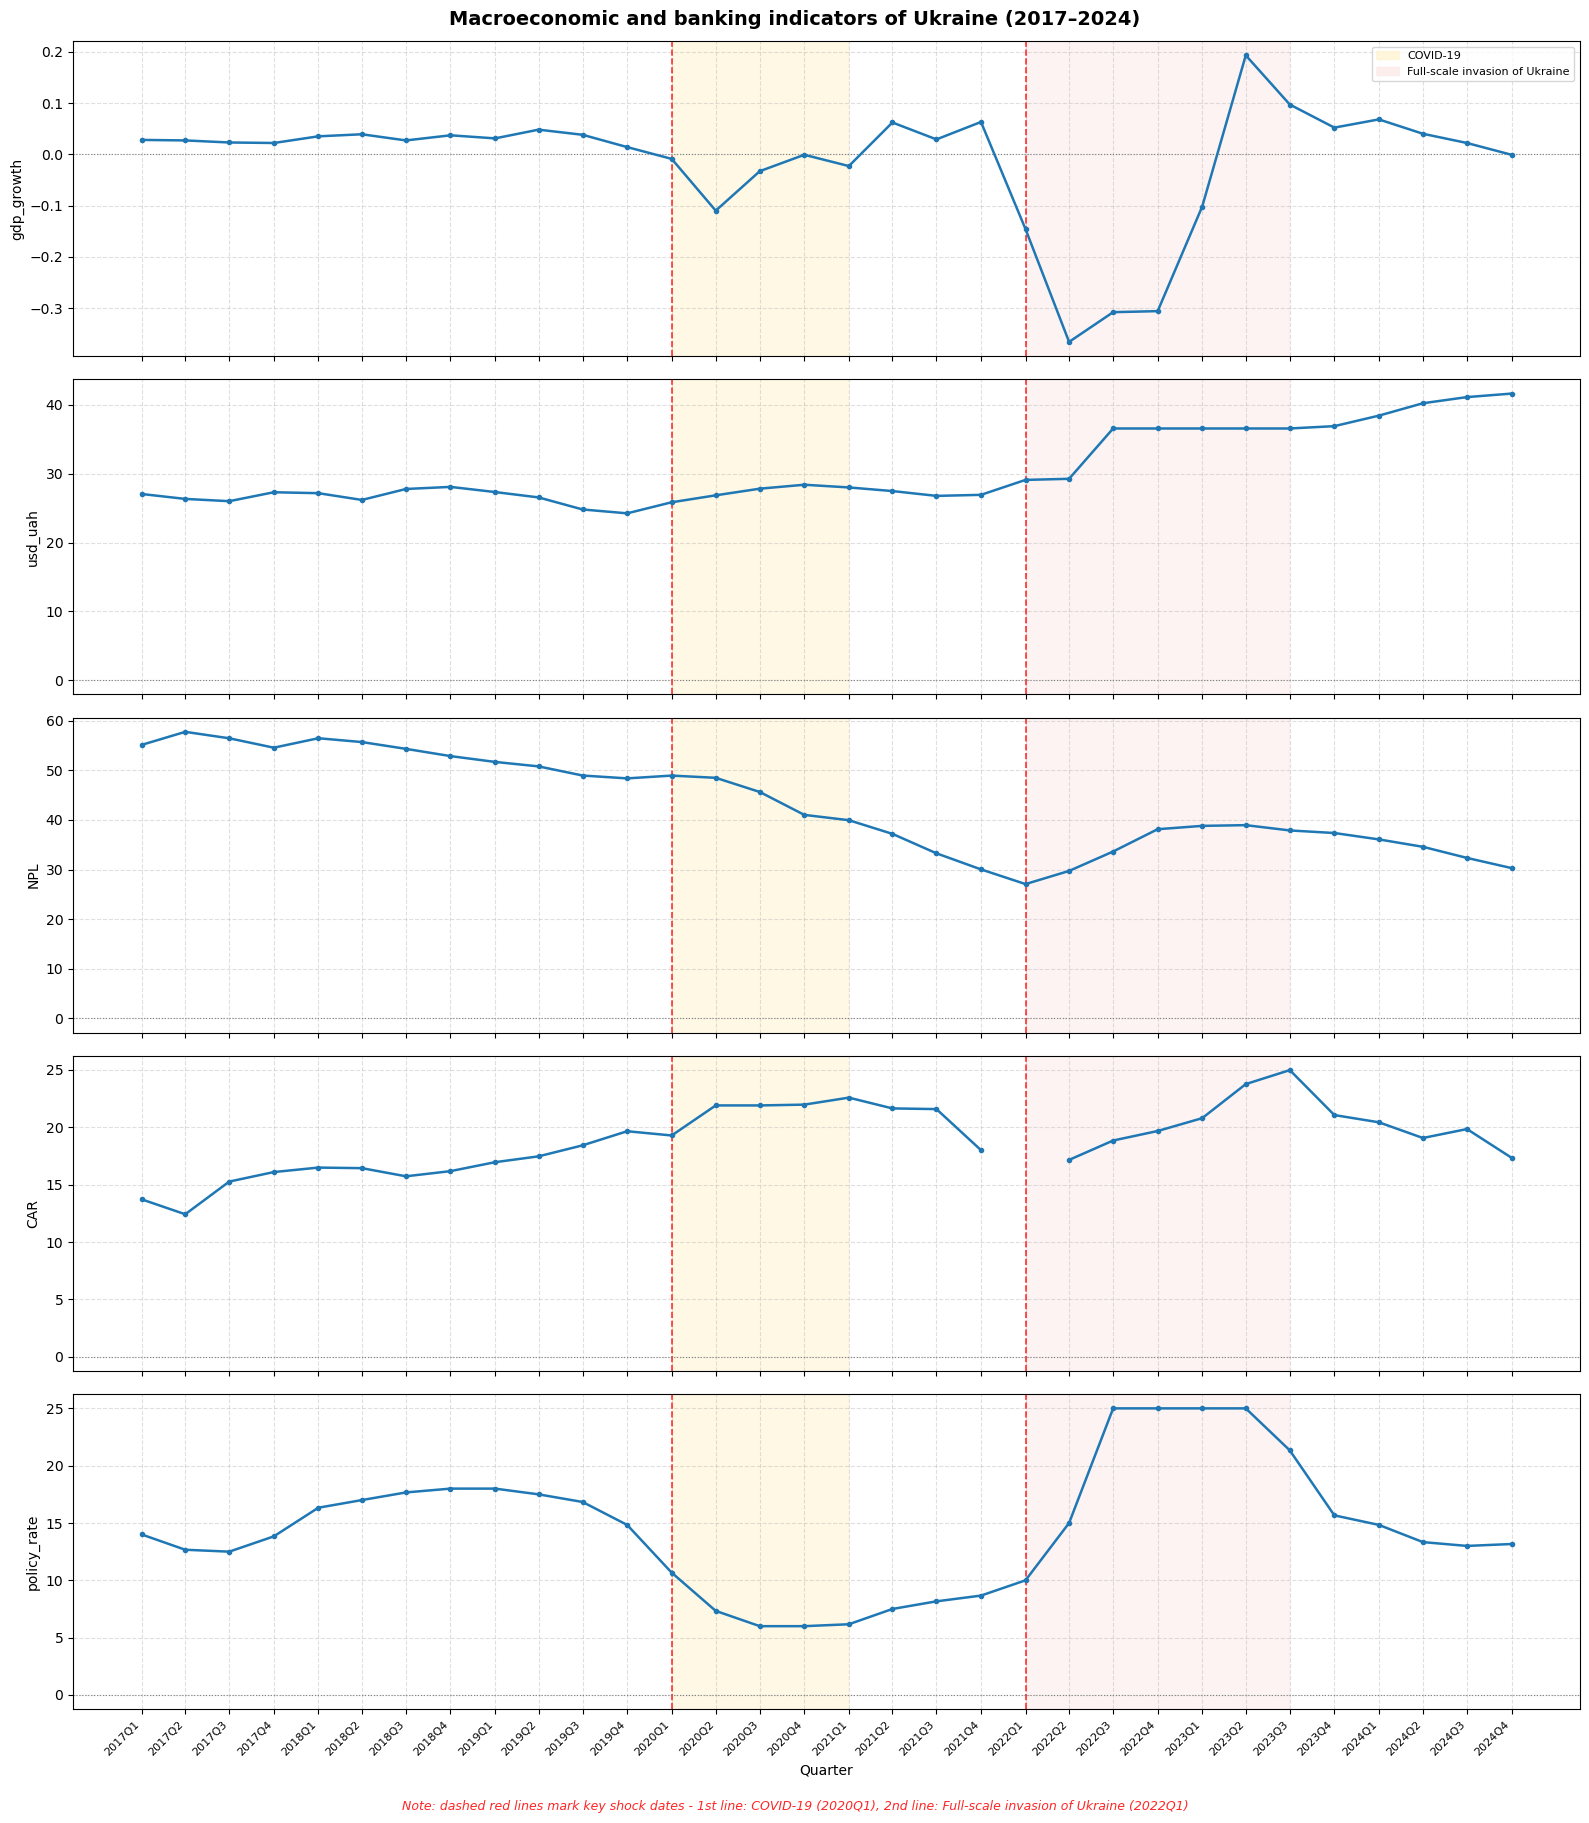

In [20]:
key_vars = ["gdp_growth", "usd_uah", "NPL", "CAR", "policy_rate"]

# Crisis events and periods
events = {
    "COVID-19 (2020Q1)":      pd.Timestamp("2020-01-01"),
    "Full-scale invasion of Ukraine (2022Q1)":    pd.Timestamp("2022-01-01"),
}
crisis_periods = [
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), "#fff3cd", "COVID-19"),
    (pd.Timestamp("2022-01-01"), pd.Timestamp("2023-06-30"), "#fde8e8", "Full-scale invasion of Ukraine"),
]

fig, axes = plt.subplots(
    nrows=len(key_vars), ncols=1,
    figsize=(16, 18),
    sharex=True  
)
fig.suptitle("Macroeconomic and banking indicators of Ukraine (2017–2024)",
             fontsize=14, fontweight="bold", y=0.99 )

df["date_ts"] = pd.PeriodIndex(df["date"], freq="Q").to_timestamp()

for ax, col in zip(axes, key_vars):
    for start, end, color, label in crisis_periods:
        ax.axvspan(start, end, color=color, alpha=0.5, label=label)
    for label, date in events.items():
        ax.axvline(date, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.plot(df["date_ts"], df[col],
            marker="o", markersize=3,
            linewidth=1.8, color="#1f77b4")
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    if col == key_vars[0]:
        patches = [
            mpatches.Patch(color="#fff3cd", alpha=0.7, label="COVID-19"),
            mpatches.Patch(color="#fde8e8", alpha=0.7, label="Full-scale invasion of Ukraine"),
        ]
        ax.legend(handles=patches, loc="upper right", fontsize=8)
        
quarter_ticks  = df["date_ts"]                                 
quarter_labels = df["date"]
axes[-1].set_xticks(quarter_ticks)
axes[-1].set_xticklabels(quarter_labels, rotation=45, ha="right", fontsize=8)
axes[-1].set_xlabel("Quarter", fontsize=10)
fig.text(
    0.5, -0.01,
    "Note: dashed red lines mark key shock dates - "
    "1st line: COVID-19 (2020Q1), 2nd line: Full-scale invasion of Ukraine (2022Q1)",
    ha="center", fontsize=9, color="red", alpha=0.85, style="italic"
)

plt.tight_layout()
plt.show()

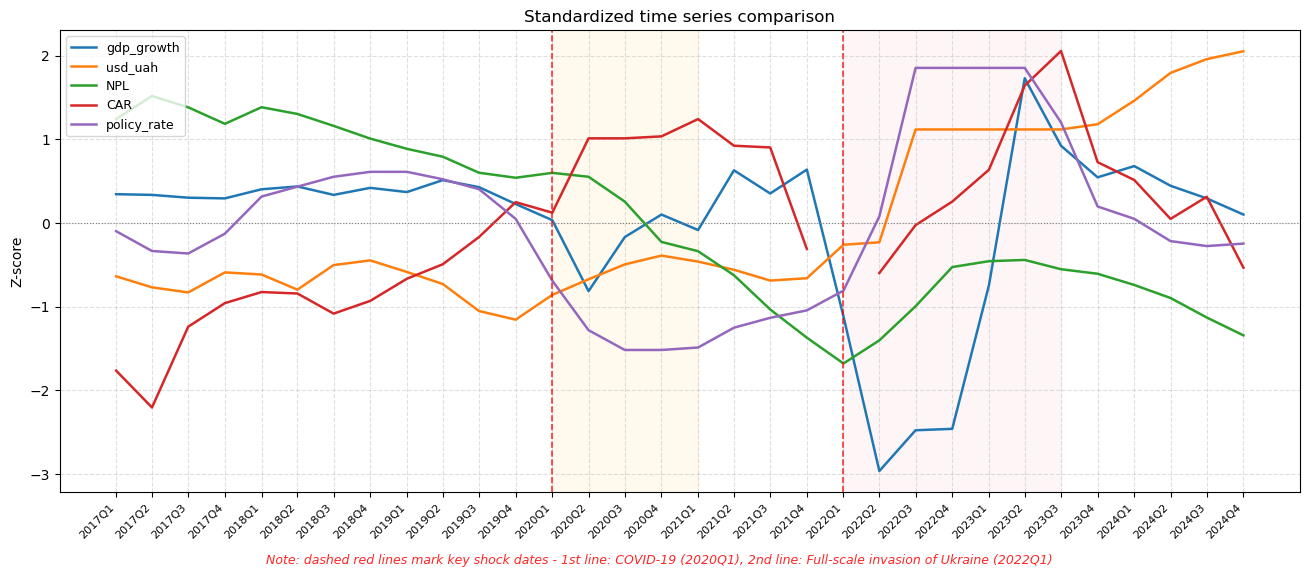

In [21]:
fig2, ax2 = plt.subplots(figsize=(16, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for col, color in zip(key_vars, colors):
    z = (df[col] - df[col].mean()) / df[col].std()   # Z-score normalization
    ax2.plot(df["date_ts"], z, label=col, linewidth=1.8, color=color)

for start, end, color, label in crisis_periods:
    ax2.axvspan(start, end, color=color, alpha=0.35)
    
for label, date in events.items():
    ax2.axvline(date, color="red", linestyle="--", linewidth=1.2, alpha=0.8)

ax2.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax2.set_xticks(quarter_ticks)
ax2.set_xticklabels(quarter_labels, rotation=45, ha="right", fontsize=8)
ax2.set_title("Standardized time series comparison", fontsize=12)
ax2.set_ylabel("Z-score")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.4)

fig2.text(
    0.5, -0.01,
    "Note: dashed red lines mark key shock dates - "
    "1st line: COVID-19 (2020Q1), 2nd line: Full-scale invasion of Ukraine (2022Q1)",
    ha="center", fontsize=9, color="red", alpha=0.85, style="italic"
)

plt.show()

> We can see that the full-scale invasion in 2022 produced a larger and more persistent shock than COVID-19, so henceforth we will include only it as a structural break.

## Stationarity Tests

Check whether the time series are stationary (mean and variance of each series remain constant over time).
Non-stationary variables in regression may produce biased and unreliable coefficients.

The **Augmented Dickey-Fuller test** is used (H0: series is non-stationary).

**Transformation for non-stationary variables:**

1) log-difference: `ln(x(t)) − ln(x(t-1))` 

2) first-order difference: `x(t) − x(t-1)`  

In [27]:
results = []

for col in num_cols:
    series = df[col].dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")

    stationary = adf_p < 0.05

    results.append({
        "variable"    : col,
        "ADF p-value" : round(adf_p, 3),
        "result"      : "stationary" if stationary else "non-stationary",
        "transform"   : "none" if stationary else ("log+diff" if df[col].min() > 0 else "diff")
    })

stationarity_df = pd.DataFrame(results).set_index("variable")
display(stationarity_df)

,ADF p-value,result,transform
variable,,,
CPI,0.008,stationary,none
usd_uah,0.984,non-stationary,log+diff
policy_rate,0.018,stationary,none
gdp_growth,0.022,stationary,none
NPL,0.533,non-stationary,log+diff
CAR,0.264,non-stationary,log+diff
ROA,0.096,non-stationary,diff
loans,0.037,stationary,none
capital,0.996,non-stationary,log+diff


Corrections:

`NPL`, `CAR` are percentage indicators -> apply *diff* (not log-diff)

`loans` -> apply *log+diff*

## Distribution analysis

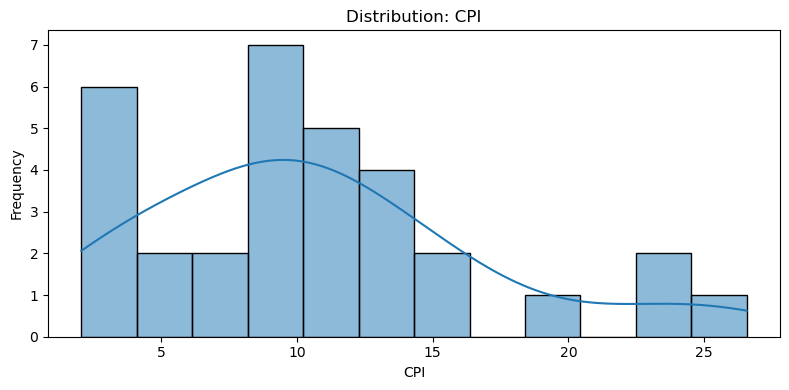

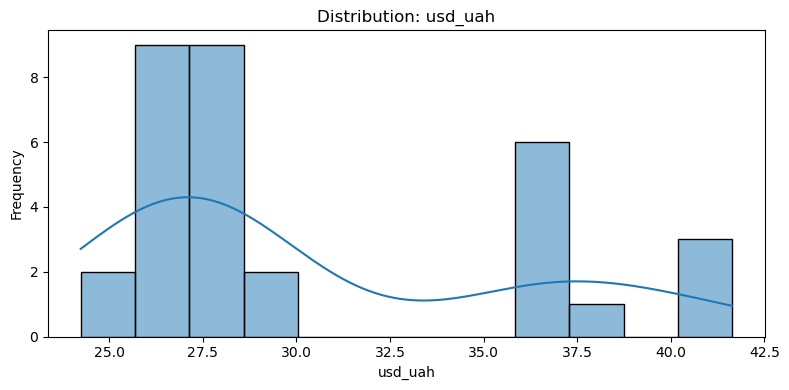

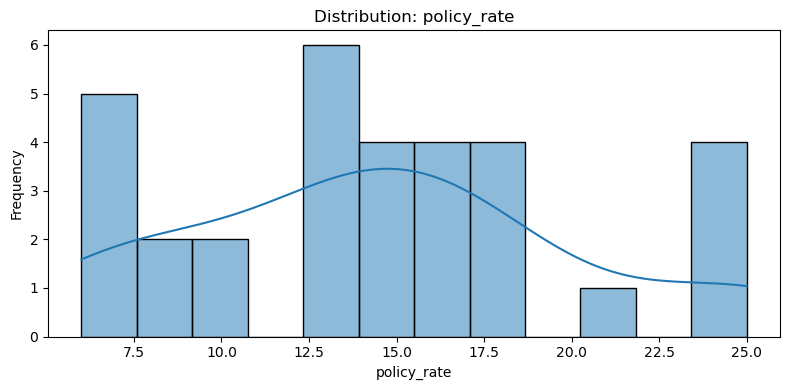

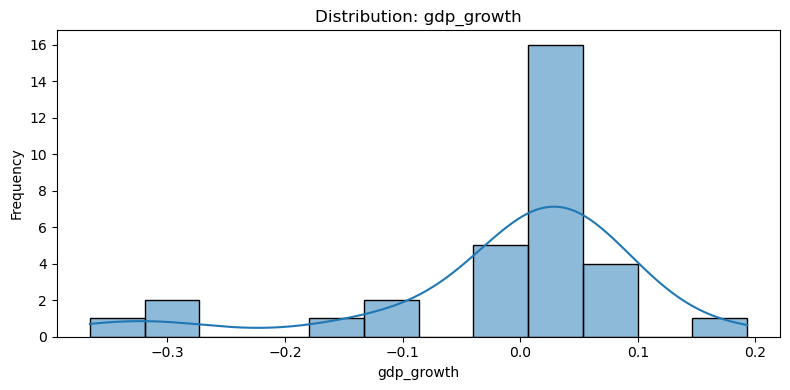

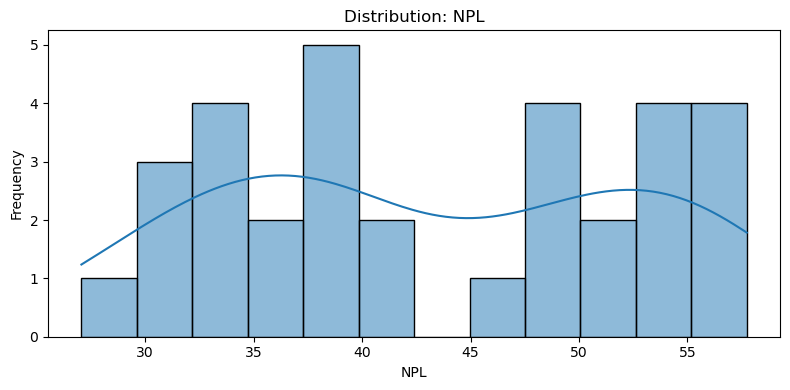

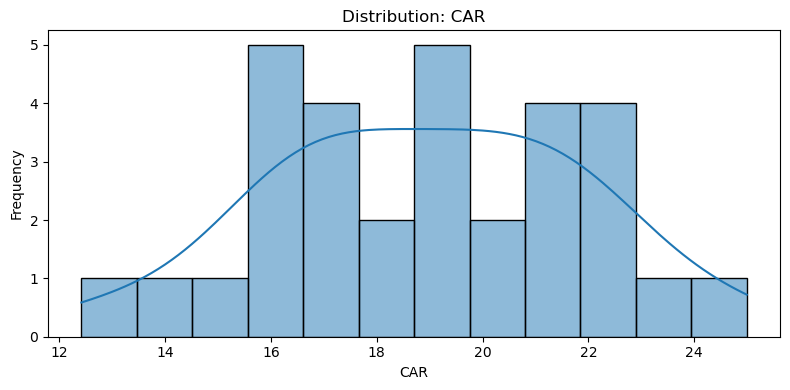

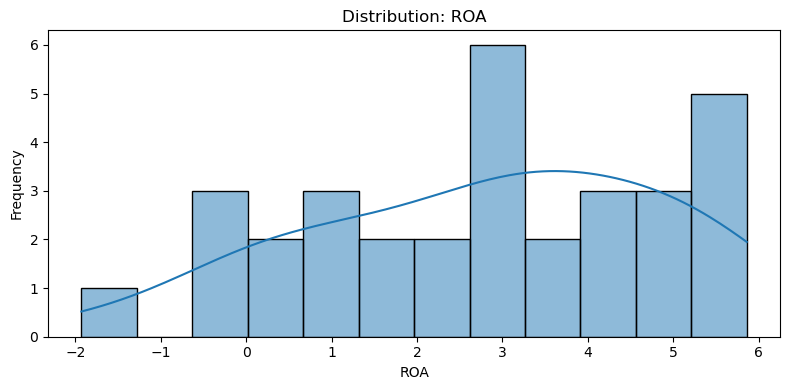

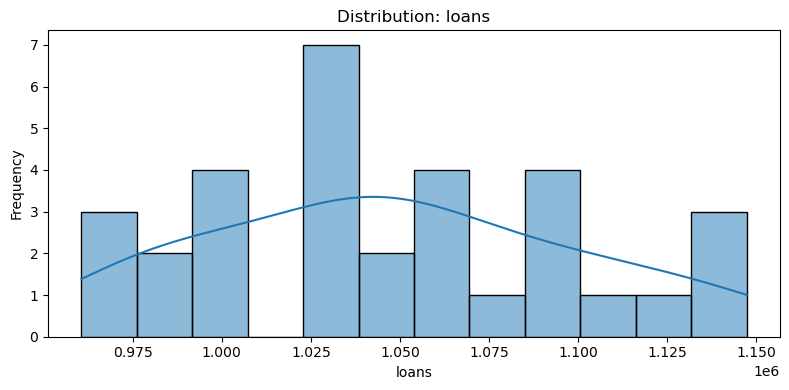

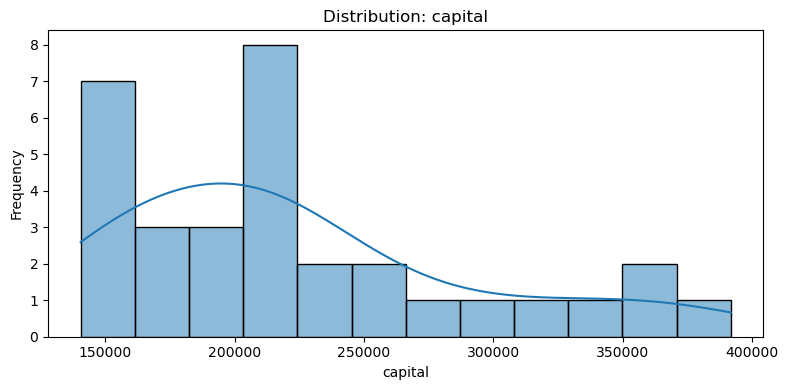

In [8]:
for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=12
    )

    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

> The distributions of most indicators appear non-normal, which is expected, considering crisis periods and limited sample size

## Outlier detection

Detect outliers -  data points that significantly differ from the rest of the dataset.

**Z-score method** is applied: if `|z| > 2.5` -> value is considered as outlier,  meaning it lies more than 2.5 standard deviations away from the average

In [9]:
z_results = []

for col in num_cols:

    mean = df[col].mean()
    std = df[col].std()
    z = (df[col] - mean) / std

    mask = np.abs(z) > 2.5

    temp = df.loc[mask, ["date"]].copy()
    temp["variable"] = col
    temp["value"] = df.loc[mask, col].values
    temp["z_score"] = z[mask].values

    z_results.append(temp)

z_outliers = pd.concat(z_results, ignore_index=True)

z_outliers = z_outliers[
    ["date", "variable", "value", "z_score"]
]

display(
    z_outliers.sort_values(["variable", "date"]).reset_index(drop=True)
)

,date,variable,value,z_score
0,2022Q4,CPI,26.566667,2.550507
1,2022Q2,gdp_growth,-0.366000,-2.965491


> 2 outliers were identified: 1)CPI in 2022Q4 2)GDP growth in 2022Q2. Both are economically meaningful (start of the full-scale war in Ukraine)

## Correlation analysis


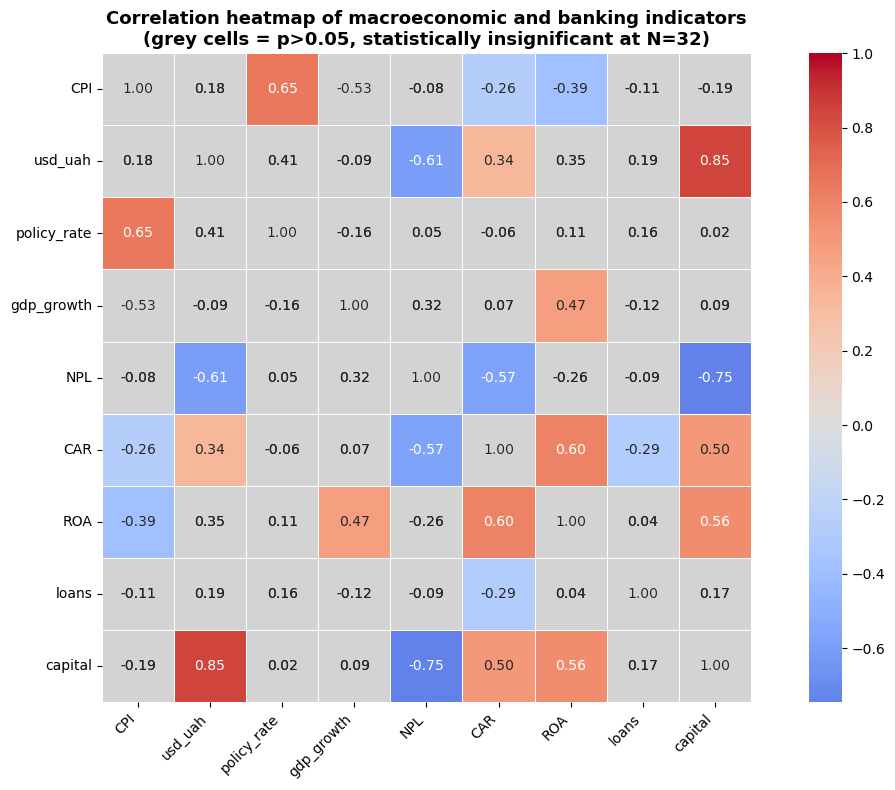

In [48]:
# calculate p-value using Spearman rank correlation

p_matrix = pd.DataFrame(np.ones((len(num_cols), len(num_cols))),
                        index=num_cols, columns=num_cols)

for c1 in num_cols:
    for c2 in num_cols:
        if c1 != c2:
            tmp = df[[c1, c2]].dropna()
            _, p = spearmanr(tmp[c1], tmp[c2])
            p_matrix.loc[c1, c2] = p

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))


sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

# grey overlay for non-significant cells (p > 0.05)
sns.heatmap(
    corr_matrix,
    mask=(p_matrix <= 0.05),  
    annot=True,
    fmt=".2f",
    cmap=["#D3D3D3"],
    linewidths=0.5,
    square=True,
    cbar=False,
    ax=ax
)

ax.set_title("Correlation heatmap of macroeconomic and banking indicators\n"
             "(grey cells = p>0.05, statistically insignificant at N=32)",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Suspicious correlations:**
- Negative correlation between `usd_uah` and  `NPL`.
- Positive correlation between `usd_uah` and `CAR`.

It's most likely such result reflect shared time trend, not direct correlation.

## Structural breaks analysis

In [46]:
break_results = []

for col in num_cols:
    pre  = pre_war[col].dropna()
    post = post_war[col].dropna()

    stat, p = mannwhitneyu(pre, post, alternative="two-sided")

    break_results.append({
        "variable"  : col,
        "pre mean"  : round(pre.mean(),  3),
        "post mean" : round(post.mean(), 3),
        "difference"    : round(post.mean() - pre.mean(), 3),
        "p-value"   : round(p,    3),
        "significant": "yes" if p < 0.05 else "no"
    })

break_df = pd.DataFrame(break_results).set_index("variable")
display(break_df)

,pre mean,post mean,difference,p-value,significant
variable,,,,,
CPI,9.093,13.311,4.218,0.220,no
usd_uah,26.846,36.628,9.782,0.000,yes
policy_rate,12.483,18.028,5.544,0.032,yes
gdp_growth,0.017,-0.063,-0.080,0.626,no
NPL,48.363,34.561,-13.801,0.000,yes
CAR,18.190,20.275,2.085,0.087,no
ROA,2.502,3.353,0.852,0.235,no
loans,1042215.026,1055731.750,13516.724,0.521,no
capital,184007.884,287022.333,103014.449,0.000,yes


> As we can see, 2022 represents a structural break point.
For the indicators **usd_uah, policy_rate, NPL, capital** the change before and after 2022 is statistically significant (p<0.05). This suggests that we should later include war dummy variables in the regression analysis.

It's important to note that we have only 12 post-war observations comparatively to 20 pre-war.